### 🔹 Step 1: Code Explanation
This cell performs part of the ML workflow.

In [150]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [151]:
df=pd.read_csv('Housing.csv')
print(df.shape)
df.sample(6)


(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
498,2660000,2000,2,1,2,yes,no,no,no,no,0,no,semi-furnished
399,3500000,7350,2,1,1,yes,no,no,no,no,1,no,semi-furnished
156,5523000,6900,3,1,1,yes,yes,yes,no,no,0,yes,semi-furnished
408,3430000,4000,2,1,1,yes,no,no,no,no,0,no,unfurnished
418,3360000,3500,4,1,2,yes,no,no,no,yes,2,no,unfurnished
209,4900000,6720,3,1,1,yes,no,no,no,no,0,no,unfurnished


In [152]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating',
               'airconditioning','prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes':1, 'no':0})

# Ordinal Encoding for furnishingstatus
df['furnishingstatus'] = df['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})


In [153]:
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['area_bedrooms'] = df['area'] * df['bedrooms']
df['is_luxury'] = (df['area'] > 4000).astype(int)

In [154]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,area_bedrooms,is_luxury
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2,6,29680,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2,8,35840,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,5,29880,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2,6,30000,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2,5,29680,1


<Axes: ylabel='price'>

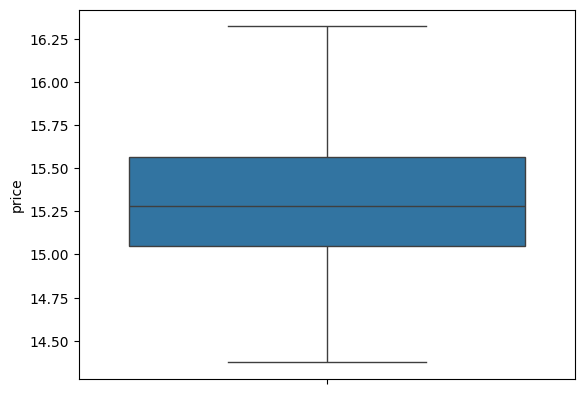

In [155]:
import seaborn as sns
df['price'] = np.log(df['price'])
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

sns.boxplot(df['price'])

In [156]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [157]:
numerical_cols = X.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols)
])

In [158]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(random_state=42)
}


results = []

for name, model in models.items():
    
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2": round(r2, 3),
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3)
    })
results_df = pd.DataFrame(results)

# Sort by best R2 (descending)
results_df = results_df.sort_values(by="R2", ascending=False)

print("\n📊 Model Comparison:\n")
print(results_df)


📊 Model Comparison:

               Model     R2    MAE   RMSE
1              Ridge  0.720  0.171  0.223
0  Linear Regression  0.718  0.172  0.223
4      Random Forest  0.636  0.192  0.254
3      Decision Tree  0.432  0.241  0.317
2              Lasso -0.007  0.345  0.422


In [159]:
best_model_name = results_df.iloc[0]["Model"]

print(f"\n🏆 Best Model: {best_model_name}")

# Optional: get best pipeline
best_pipeline = None

for name, model in models.items():
    if name == best_model_name:
        best_pipeline = Pipeline([
            ("preprocessing", preprocessor),
            ("model", model)
        ])
        best_pipeline.fit(X_train, y_train)


🏆 Best Model: Ridge


In [160]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10, 100]
}

grid = GridSearchCV(
    best_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

final_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'model__alpha': 100}


In [161]:
y_pred = final_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.7209782976380026
MAE: 0.17085421692624306
RMSE: 0.22237103094126298


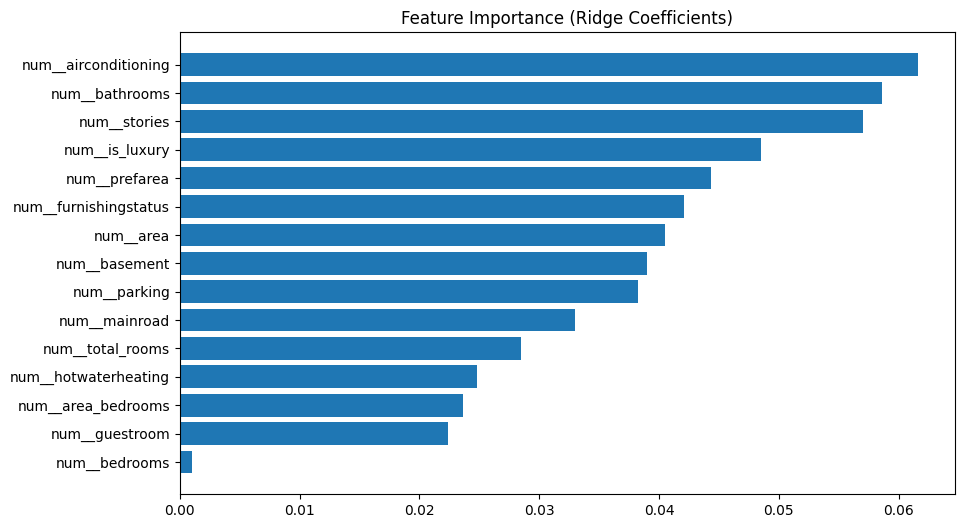

In [162]:
import matplotlib.pyplot as plt
import pandas as pd

model = final_model.named_steps['model']

# Get feature names (IMPORTANT if using preprocessing)
feature_names = final_model.named_steps['preprocessing'].get_feature_names_out()

coefficients = model.coef_

# Create dataframe
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title("Feature Importance (Ridge Coefficients)")
plt.gca().invert_yaxis()
plt.show()

In [163]:
import pickle

pickle.dump(final_model, open("house_price_model.pkl", "wb"))

In [166]:

import pickle
import pandas as pd
import numpy as np

try:
    model = pickle.load(open("house_price_model.pkl", "rb"))
    print("✅ Model loaded successfully")
except Exception as e:
    print("❌ Error loading model:", e)
    exit()


def format_price(price):
    if price >= 10000000:
        return f"{round(price/10000000, 2)} Cr"
    else:
        return f"{round(price/100000, 2)} Lakh"


def predict_price(input_data):
    try:
        df = pd.DataFrame([input_data])

        # ✅ Feature Engineering (IMPORTANT)
        df['total_rooms'] = df['bedrooms'] + df['bathrooms']
        df['area_bedrooms'] = df['area'] * df['bedrooms']
        df['is_luxury'] = (df['area'] > 4000).astype(int)

        # ✅ Prediction (log scale)
        pred_log = model.predict(df)

        # ✅ Convert back to actual price
        price = np.exp(pred_log)[0]

        return price

    except Exception as e:
        print("❌ Prediction error:", e)
        return None


# ------------------------------------------
# 4. Sample Input (CHANGE VALUES HERE)
# ------------------------------------------
sample_input = {
    'area': 1500,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'parking': 1,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 0,
    'hotwaterheating': 0,
    'airconditioning': 1 ,
    'prefarea': 1,
    'furnishingstatus': '1'
}


# ------------------------------------------
# 5. Run Prediction
# ------------------------------------------
price = predict_price(sample_input)

if price:
    print(f"\n🏠 Predicted Price: ₹ {format_price(price)}")
else:
    print("⚠️ Prediction failed")



✅ Model loaded successfully

🏠 Predicted Price: ₹ 50.03 Lakh
